# Tarefa 2 — Prophet, MLP (Sliding Window) e LSTM

**Disciplina:** Séries Temporais e Sistemas de Recomendação  
**Dataset:** UKgas — consumo trimestral de gás no Reino Unido  
**Divisão:** 81 observações para treinamento e 27 para teste.

> Este notebook foi organizado para executar integralmente os itens **(a)–(e)** da atividade.  
> O dataset é incorporado ao notebook para evitar dependência de download externo durante a execução.

## 1. Instalação e importação das bibliotecas

> Execute esta célula uma vez no Google Colab/Jupyter. Se as bibliotecas já estiverem instaladas, o comando `pip` não precisa ser executado novamente.

In [1]:
# Instalação das bibliotecas necessárias
%pip install -q prophet tensorflow scikit-learn pandas numpy matplotlib

In [2]:
import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = True

## 2. Dataset UKgas

O conjunto possui **108 observações trimestrais**, de 1960 Q1 até 1986 Q4. Os valores abaixo correspondem ao dataset UKgas utilizado na atividade.

**Fonte de referência do dataset:** documentação do R `datasets::UKgas`.

In [3]:
# Dados UKgas — 108 observações trimestrais
ukgas_values = [160.1, 129.7, 84.8, 120.1, 160.1, 124.9, 84.8, 116.9, 169.7, 140.9, 89.7, 123.3, 187.3, 144.1, 92.9, 120.1, 176.1, 147.3, 89.7, 123.3, 185.7, 155.3, 99.3, 131.3, 200.1, 161.7, 102.5, 136.1, 204.9, 176.1, 112.1, 140.9, 227.3, 195.3, 115.3, 142.5, 244.9, 214.5, 118.5, 153.7, 244.9, 216.1, 188.9, 142.5, 301.0, 196.9, 136.1, 267.3, 317.0, 230.5, 152.1, 336.2, 371.4, 240.1, 158.5, 355.4, 449.9, 286.6, 179.3, 403.4, 491.5, 321.8, 177.7, 409.8, 593.9, 329.8, 176.1, 483.5, 584.3, 395.4, 187.3, 485.1, 669.2, 421.0, 216.1, 509.1, 827.7, 467.5, 209.7, 542.7, 840.5, 414.6, 217.7, 670.8, 848.5, 437.0, 209.7, 701.2, 925.3, 443.4, 214.5, 683.6, 917.3, 515.5, 224.1, 694.8, 989.4, 477.1, 233.7, 730.0, 1087.0, 534.7, 281.8, 787.6, 1163.9, 613.1, 347.4, 782.8]

datas = pd.date_range(
    start="1960-01-01",
    periods=len(ukgas_values),
    freq="QS"
)

df = pd.DataFrame({
    "ds": datas,
    "y": ukgas_values
})

serie_gas = pd.Series(
    df["y"].values,
    index=df["ds"]
)

print(f"Total de observações: {len(df)}")
print(f"Período: {df['ds'].min().date()} até {df['ds'].max().date()}")
df.head()

Total de observações: 108
Período: 1960-01-01 até 1986-10-01


,ds,y
0,1960-01-01,160.1
1,1960-04-01,129.7
2,1960-07-01,84.8
3,1960-10-01,120.1
4,1961-01-01,160.1


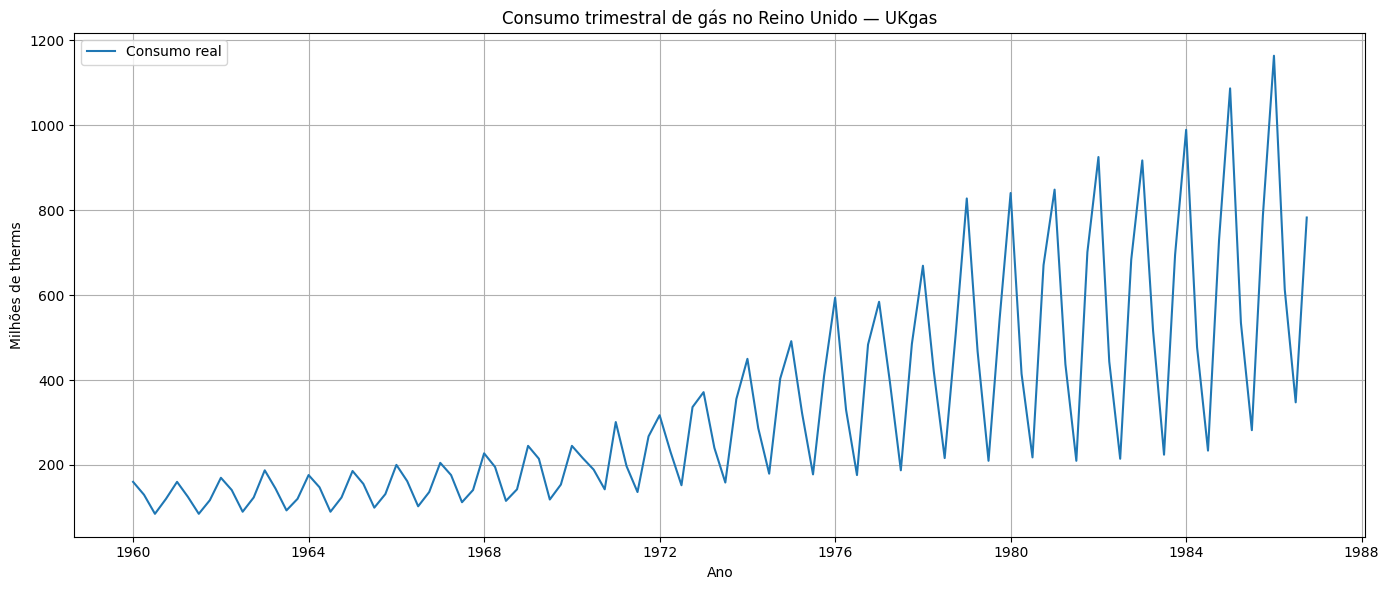

In [4]:
plt.figure(figsize=(14, 6))
plt.plot(df["ds"], df["y"], label="Consumo real")
plt.title("Consumo trimestral de gás no Reino Unido — UKgas")
plt.xlabel("Ano")
plt.ylabel("Milhões de therms")
plt.legend()
plt.tight_layout()
plt.show()

# Item A — Divisão da base

A atividade solicita aproximadamente **75% para treinamento (81 observações)** e **25% para teste (27 observações)**. Como se trata de uma série temporal, a divisão é feita cronologicamente, sem embaralhamento.

Dados de treinamento: 81 observações
Dados de teste:       27 observações
Total:                108 observações


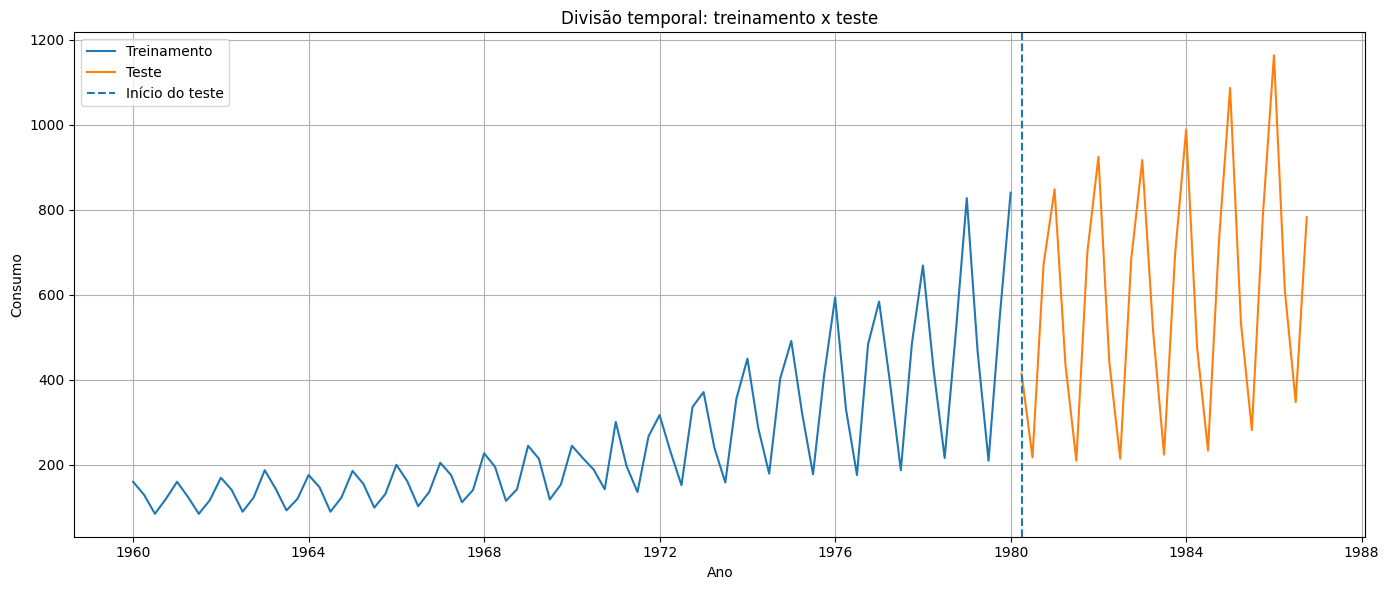

In [5]:
N_TREINO = 81
N_TESTE = 27

dataset_treino = df.iloc[:N_TREINO].copy()
dataset_teste = df.iloc[N_TREINO:].copy()

y_treino = dataset_treino["y"].to_numpy()
y_teste = dataset_teste["y"].to_numpy()

print(f"Dados de treinamento: {len(dataset_treino)} observações")
print(f"Dados de teste:       {len(dataset_teste)} observações")
print(f"Total:                {len(df)} observações")

plt.figure(figsize=(14, 6))
plt.plot(dataset_treino["ds"], dataset_treino["y"], label="Treinamento")
plt.plot(dataset_teste["ds"], dataset_teste["y"], label="Teste")
plt.axvline(dataset_teste["ds"].iloc[0], linestyle="--", label="Início do teste")
plt.title("Divisão temporal: treinamento x teste")
plt.xlabel("Ano")
plt.ylabel("Consumo")
plt.legend()
plt.tight_layout()
plt.show()

# Item B — Prophet

O Prophet recebe a série no formato `ds` (data) e `y` (valor). O modelo é treinado somente com as 81 observações de treinamento e gera previsão para os 27 períodos do conjunto de teste.

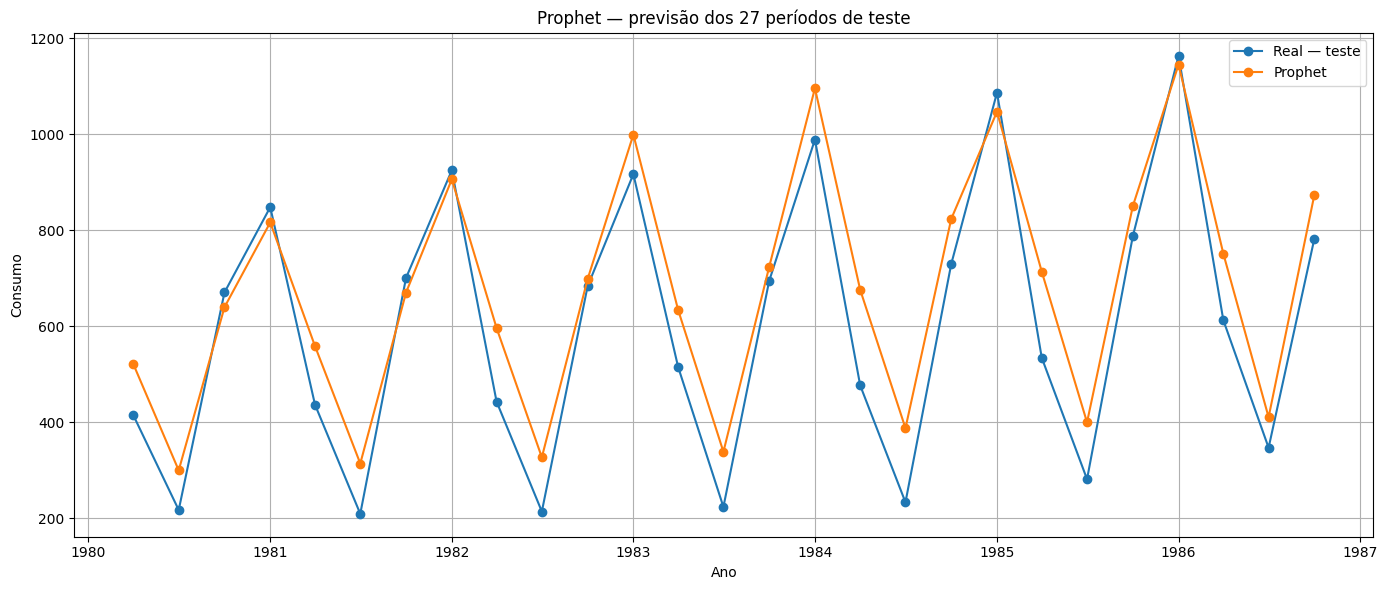

In [6]:
modelo_prophet = Prophet(
    growth="linear",
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.5,
    seasonality_prior_scale=10.0,
    interval_width=0.95
)

modelo_prophet.fit(dataset_treino[["ds", "y"]])

datas_futuras = dataset_teste[["ds"]].copy()
previsao_prophet_df = modelo_prophet.predict(datas_futuras)

previsao_prophet = previsao_prophet_df["yhat"].to_numpy()

plt.figure(figsize=(14, 6))
plt.plot(dataset_teste["ds"], y_teste, marker="o", label="Real — teste")
plt.plot(dataset_teste["ds"], previsao_prophet, marker="o", label="Prophet")
plt.title("Prophet — previsão dos 27 períodos de teste")
plt.xlabel("Ano")
plt.ylabel("Consumo")
plt.legend()
plt.tight_layout()
plt.show()

# Item C — MLP com Sliding Window

Será utilizada uma rede neural multicamadas (**MLP**) com estratégia **sliding window**.

- Tamanho da janela: 8 observações.
- Cada janela contém os 8 valores anteriores.
- O próximo valor é o alvo.
- Para prever os 27 períodos de teste, a previsão é realizada de forma recursiva, incorporando cada previsão à janela seguinte.
- O `MinMaxScaler` é ajustado somente com os dados de treinamento.

In [7]:
WINDOW_SIZE = 8

# Escalonamento sem vazamento de informação do conjunto de teste
scaler_mlp = MinMaxScaler()
treino_scaled = scaler_mlp.fit_transform(y_treino.reshape(-1, 1)).flatten()

def criar_janelas(serie, window_size):
    X, y = [], []
    for i in range(window_size, len(serie)):
        X.append(serie[i-window_size:i])
        y.append(serie[i])
    return np.array(X), np.array(y)

X_mlp, y_mlp = criar_janelas(treino_scaled, WINDOW_SIZE)

print("Formato de X:", X_mlp.shape)
print("Formato de y:", y_mlp.shape)

Formato de X: (73, 8)
Formato de y: (73,)


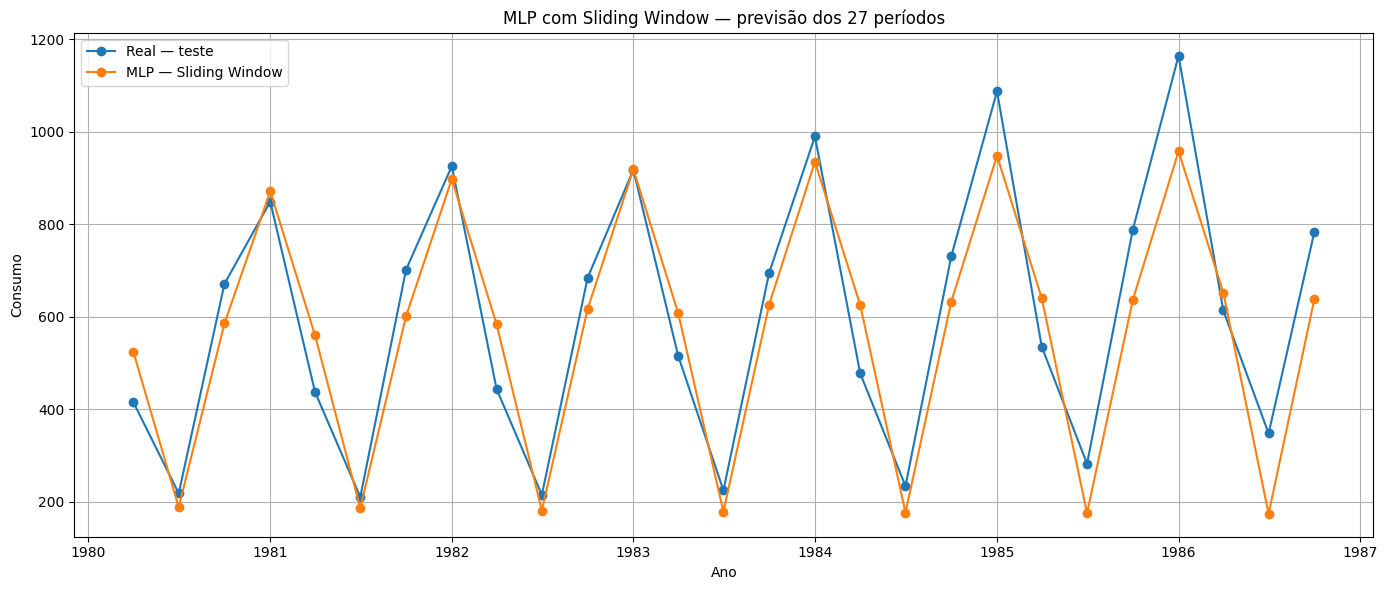

In [8]:
modelo_mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=3000,
    random_state=SEED,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=100
)

modelo_mlp.fit(X_mlp, y_mlp)

# Previsão recursiva dos 27 períodos
janela = treino_scaled[-WINDOW_SIZE:].copy()
previsoes_mlp_scaled = []

for _ in range(N_TESTE):
    entrada = janela.reshape(1, -1)
    proximo = modelo_mlp.predict(entrada)[0]
    previsoes_mlp_scaled.append(proximo)
    janela = np.append(janela[1:], proximo)

previsao_mlp = scaler_mlp.inverse_transform(
    np.array(previsoes_mlp_scaled).reshape(-1, 1)
).flatten()

plt.figure(figsize=(14, 6))
plt.plot(dataset_teste["ds"], y_teste, marker="o", label="Real — teste")
plt.plot(dataset_teste["ds"], previsao_mlp, marker="o", label="MLP — Sliding Window")
plt.title("MLP com Sliding Window — previsão dos 27 períodos")
plt.xlabel("Ano")
plt.ylabel("Consumo")
plt.legend()
plt.tight_layout()
plt.show()

# Item D — LSTM

A LSTM também será treinada usando janelas temporais de 8 observações.

A entrada da LSTM possui o formato:

`[amostras, passos_temporais, características]`

Neste caso:

- amostras = número de janelas de treinamento;
- passos temporais = 8;
- características = 1, o consumo de gás.

In [9]:
scaler_lstm = MinMaxScaler()
treino_lstm_scaled = scaler_lstm.fit_transform(y_treino.reshape(-1, 1))

def criar_janelas_lstm(serie, window_size):
    X, y = [], []
    for i in range(window_size, len(serie)):
        X.append(serie[i-window_size:i, 0])
        y.append(serie[i, 0])
    return np.array(X), np.array(y)

X_lstm, y_lstm = criar_janelas_lstm(treino_lstm_scaled, WINDOW_SIZE)

X_lstm = X_lstm.reshape((X_lstm.shape[0], X_lstm.shape[1], 1))

print("Formato de X:", X_lstm.shape)
print("Formato de y:", y_lstm.shape)

Formato de X: (73, 8, 1)
Formato de y: (73,)


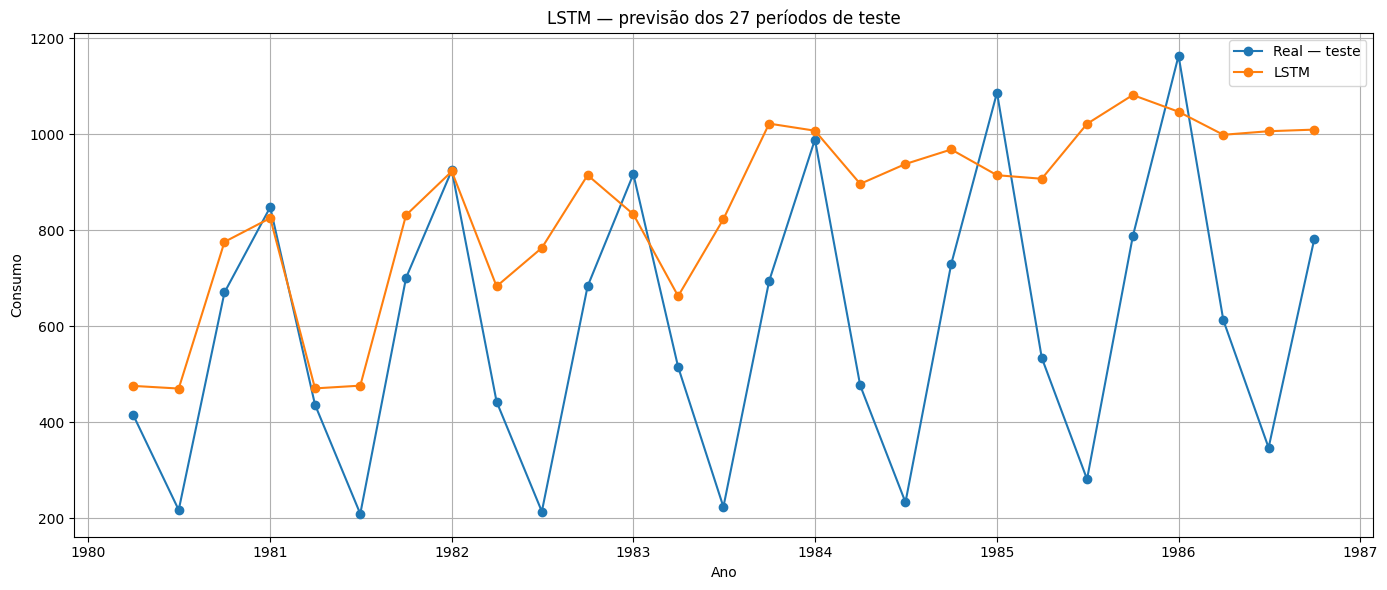

In [10]:
modelo_lstm = Sequential([
    Input(shape=(WINDOW_SIZE, 1)),
    LSTM(64, activation="tanh"),
    Dense(32, activation="relu"),
    Dense(1)
])

modelo_lstm.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=40,
    restore_best_weights=True
)

historico_lstm = modelo_lstm.fit(
    X_lstm,
    y_lstm,
    epochs=500,
    batch_size=8,
    validation_split=0.15,
    shuffle=False,
    callbacks=[early_stop],
    verbose=0
)

# Previsão recursiva
janela_lstm = treino_lstm_scaled[-WINDOW_SIZE:].reshape(WINDOW_SIZE, 1).copy()
previsoes_lstm_scaled = []

for _ in range(N_TESTE):
    entrada = janela_lstm.reshape(1, WINDOW_SIZE, 1)
    proximo = modelo_lstm.predict(entrada, verbose=0)[0, 0]
    previsoes_lstm_scaled.append(proximo)
    janela_lstm = np.vstack([janela_lstm[1:], [[proximo]]])

previsao_lstm = scaler_lstm.inverse_transform(
    np.array(previsoes_lstm_scaled).reshape(-1, 1)
).flatten()

plt.figure(figsize=(14, 6))
plt.plot(dataset_teste["ds"], y_teste, marker="o", label="Real — teste")
plt.plot(dataset_teste["ds"], previsao_lstm, marker="o", label="LSTM")
plt.title("LSTM — previsão dos 27 períodos de teste")
plt.xlabel("Ano")
plt.ylabel("Consumo")
plt.legend()
plt.tight_layout()
plt.show()

# Item E — Comparação dos modelos

Nesta etapa serão apresentados:

1. Um gráfico único com as previsões dos três modelos e os valores reais;
2. Uma tabela com **MAE, MSE, RMSE e R²**;
3. Uma conclusão automática baseada nas métricas calculadas sobre o mesmo conjunto de teste.

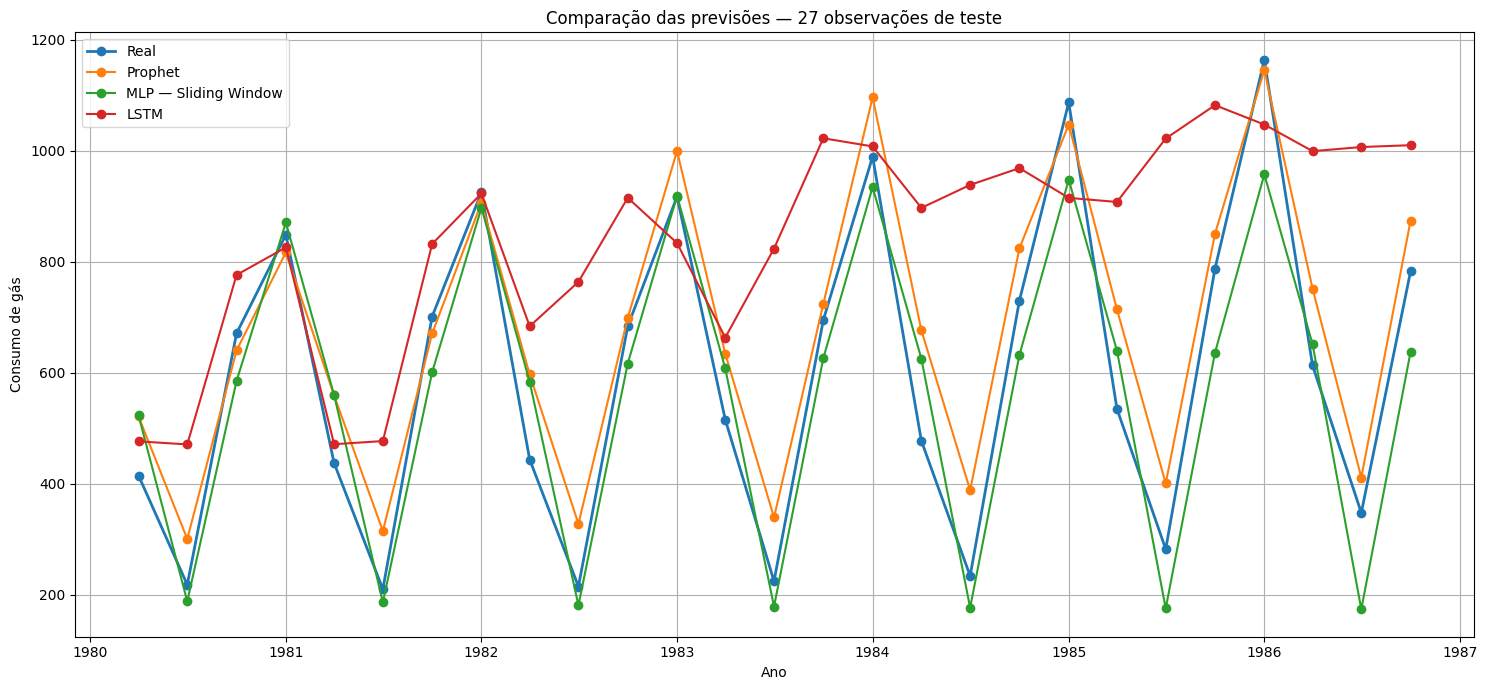

In [11]:
# Gráfico comparativo
plt.figure(figsize=(15, 7))

plt.plot(
    dataset_teste["ds"], y_teste,
    marker="o", linewidth=2,
    label="Real"
)

plt.plot(
    dataset_teste["ds"], previsao_prophet,
    marker="o",
    label="Prophet"
)

plt.plot(
    dataset_teste["ds"], previsao_mlp,
    marker="o",
    label="MLP — Sliding Window"
)

plt.plot(
    dataset_teste["ds"], previsao_lstm,
    marker="o",
    label="LSTM"
)

plt.title("Comparação das previsões — 27 observações de teste")
plt.xlabel("Ano")
plt.ylabel("Consumo de gás")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
def calcular_metricas(y_real, y_pred):
    mse = mean_squared_error(y_real, y_pred)
    return {
        "MAE": mean_absolute_error(y_real, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R²": r2_score(y_real, y_pred)
    }

metricas = pd.DataFrame({
    "Prophet": calcular_metricas(y_teste, previsao_prophet),
    "MLP — Sliding Window": calcular_metricas(y_teste, previsao_mlp),
    "LSTM": calcular_metricas(y_teste, previsao_lstm)
}).T

metricas = metricas[["MAE", "MSE", "RMSE", "R²"]]

print("Métricas no conjunto de teste:")
display(metricas.round(4))

Métricas no conjunto de teste:


,MAE,MSE,RMSE,R²
Prophet,89.6497,10594.1391,102.9278,0.8632
MLP — Sliding Window,88.7166,10576.5494,102.8424,0.8635
LSTM,274.3139,120738.0778,347.4739,-0.5587


In [13]:
# Identificação automática do modelo com melhor resultado em cada métrica
melhor_mae = metricas["MAE"].idxmin()
melhor_mse = metricas["MSE"].idxmin()
melhor_rmse = metricas["RMSE"].idxmin()
melhor_r2 = metricas["R²"].idxmax()

print("Melhor resultado por métrica:")
print(f"• Menor MAE:  {melhor_mae}")
print(f"• Menor MSE:  {melhor_mse}")
print(f"• Menor RMSE: {melhor_rmse}")
print(f"• Maior R²:   {melhor_r2}")

# Contagem simples de liderança nas quatro métricas.
liderancas = pd.Series({
    melhor_mae: 0,
    melhor_mse: 0,
    melhor_rmse: 0,
    melhor_r2: 0
}).groupby(level=0).size()

# Recontagem robusta
contagem = {modelo: 0 for modelo in metricas.index}
for vencedor in [melhor_mae, melhor_mse, melhor_rmse, melhor_r2]:
    contagem[vencedor] += 1

modelo_com_mais_liderancas = max(contagem, key=contagem.get)

print("\nConclusão:")
print(
    "As métricas devem ser interpretadas conjuntamente. "
    "Para MAE, MSE e RMSE, valores menores indicam menor erro de previsão. "
    "Para R², valores maiores indicam maior capacidade de explicar a variabilidade "
    "dos dados de teste."
)
print(
    f"Considerando a quantidade de métricas em que cada modelo apresentou o melhor "
    f"resultado, o modelo com mais lideranças foi: {modelo_com_mais_liderancas}."
)

Melhor resultado por métrica:
• Menor MAE:  MLP — Sliding Window
• Menor MSE:  MLP — Sliding Window
• Menor RMSE: MLP — Sliding Window
• Maior R²:   MLP — Sliding Window

Conclusão:
As métricas devem ser interpretadas conjuntamente. Para MAE, MSE e RMSE, valores menores indicam menor erro de previsão. Para R², valores maiores indicam maior capacidade de explicar a variabilidade dos dados de teste.
Considerando a quantidade de métricas em que cada modelo apresentou o melhor resultado, o modelo com mais lideranças foi: MLP — Sliding Window.


## Conclusão para a atividade

A conclusão final deve ser baseada na tabela de métricas produzida acima. Em geral:

- **MAE:** mede o erro absoluto médio; quanto menor, melhor.
- **MSE:** penaliza mais fortemente erros grandes; quanto menor, melhor.
- **RMSE:** está na mesma unidade do consumo e também deve ser minimizado.
- **R²:** indica quanto da variabilidade dos dados de teste é explicada pelo modelo; quanto maior, melhor.

O modelo que apresentar simultaneamente erros menores e R² maior oferece evidências de melhor ajuste **para este conjunto de teste específico**. Como os três modelos possuem características diferentes, também é importante observar o gráfico para verificar tendência, sazonalidade e possíveis desvios sistemáticos.